In [1]:
pip install osmnx networkx pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 34.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 33.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 35.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 37.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 37.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 35.3 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 37.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  0/15 [pyproj]  WARNING: The script pyproj is installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH

In [ ]:
import osmnx as ox
import networkx as nx
import pandas as pd
import time

# -----------------------------------
# 1️⃣ Bombay/Mumbai Bounding Box
# -----------------------------------
# left, bottom, right, top
west = 72.7752
south = 18.8928
east = 72.9865
north = 19.2711

print("Downloading Mumbai road network...")
G = ox.graph_from_bbox((west, south, east, north), network_type="drive")
print("Road network downloaded successfully!\n")

# -----------------------------------
# 2️⃣ Extract Hospitals Around Mumbai
# -----------------------------------
print("Extracting train stations from OpenStreetMap...")

tags = {"railway": "station"}

# correct function for your OSMnx version
pois = ox.features_from_bbox((west, south, east, north), tags)

# keep only those with a name
pois = pois[["name", "geometry"]].dropna()

# convert to lat/lon
pois["latitude"] = pois.geometry.centroid.y
pois["longitude"] = pois.geometry.centroid.x

print(f"{len(pois)} stations found!\n")

# Optional: Save dataset
pois[["name", "latitude", "longitude"]].to_csv("hospitals_mumbai.csv", index=False)

Road network downloaded successfully!

Extracting hospitals from OpenStreetMap...
152 hospitals found!



/tmp/ipykernel_18803/3380807844.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois["latitude"] = pois.geometry.centroid.y
/tmp/ipykernel_18803/3380807844.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois["longitude"] = pois.geometry.centroid.x


Train Stations:

0. Dahisar
1. Santa Cruz
2. Thane
3. Khar Road
4. Kanjur Marg
5. Vidyavihar
6. Lower Parel
7. Grant Road
8. Chembur
9. Bhakti Park
10. Wadala Depot
11. Sewri
12. Cotton Green
13. Mysore Colony
14. Mulund
15. King's Circle
16. Sandhurst Road
17. Dockyard Road
18. Reay Road
19. Currey Road
20. Chembur
21. Mankhurd
22. Nahur
23. Bandra
24. Byculla
25. Charni Road
26. Dadar
27. Dadar
28. Mahim Junction
29. Marine Lines
30. Mumbai Central
31. Vile Parle
32. Bharat Petroleum
33. VNP & RC Marg Junction
34. Chuna Bhatti
35. Sion
36. Fertilizer Township
37. Govandi
38. Bhandup
39. Borivali
40. Kandivali
41. Malad
42. Goregaon
43. Prabhadevi
44. Chinchpokli
45. Parel
46. Tilak Nagar
47. Wadala Bridge
48. Acharya Atre Nagar
49. Ambedkar Nagar
50. Dadar East
51. Guru Tegh Bahadur Nagar
52. Sant Gadge Maharaj Chowk
53. Mint Colony
54. Naigaon
55. Vikhroli
56. Churchgate
57. Matunga
58. Matunga Road
59. Mahalaxmi
60. Ghatkopar
61. Guru Tegh Bahadur Nagar
62. Dahanukarwadi
63. Kandiv


Running Dijkstra Algorithm...

Shortest Distance: 12040.44 meters
Execution Time: 0.0304 seconds

Displaying route on map...


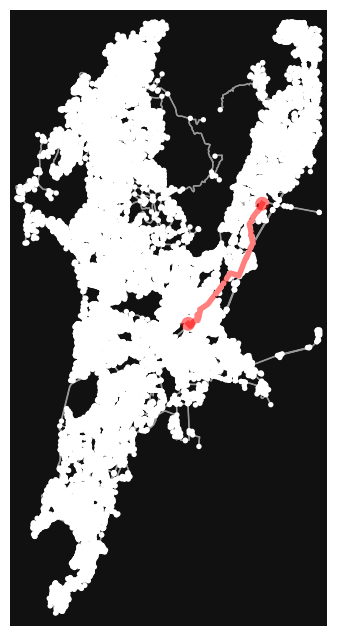

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [3]:
# -----------------------------------
# 3️⃣ Display Train Station List to User
# -----------------------------------
pois = pois.reset_index(drop=True)

print("Train Stations:\n")
for i, name in enumerate(pois["name"]):
    print(f"{i}. {name}")

source_index = int(input("\nSelect source (number): "))
dest_index = int(input("Select destination (number): "))

source = pois.iloc[source_index]
dest = pois.iloc[dest_index]

# -----------------------------------
# 4️⃣ Map to Graph Nodes
# -----------------------------------
orig_node = ox.distance.nearest_nodes(G, source["longitude"], source["latitude"])
dest_node = ox.distance.nearest_nodes(G, dest["longitude"], dest["latitude"])

# -----------------------------------
# 5️⃣ Run Dijkstra Algorithm
# -----------------------------------
print("\nRunning Dijkstra Algorithm...")
start_time = time.time()

route = nx.shortest_path(G, orig_node, dest_node, weight="length")

end_time = time.time()
distance = nx.shortest_path_length(G, orig_node, dest_node, weight="length")

print("\nShortest Distance: {:.2f} meters".format(distance))
print("Execution Time: {:.4f} seconds".format(end_time - start_time))

# -----------------------------------
# 6️⃣ Plot Route
# -----------------------------------
print("\nDisplaying route on map...")
ox.plot_graph_route(G, route)

In [ ]:
df = pd.read_csv()